# 🔢 ArithmosDB — GPU Vector Database Demo

**What this notebook does:**
1. Clones the repo and compiles the CUDA library
2. Installs the Python package
3. Runs a small correctness test (compare GPU results vs NumPy brute-force)
4. Benchmarks at multiple scales
5. Visualises results

> ⚡ Make sure **Runtime → Change runtime type → T4 GPU** is selected before running.



## 0 — Environment check

In [2]:
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-keyring_1.1-1_all.deb
!dpkg -i cuda-keyring_1.1-1_all.deb
!apt-get update -qq

--2026-03-18 05:51:03--  https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-keyring_1.1-1_all.deb
Resolving developer.download.nvidia.com (developer.download.nvidia.com)... 23.212.251.219, 23.212.251.216, 23.212.251.207, ...
Connecting to developer.download.nvidia.com (developer.download.nvidia.com)|23.212.251.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4332 (4.2K) [application/x-deb]
Saving to: ‘cuda-keyring_1.1-1_all.deb’

cuda-keyring_1.1-1_ 100%[===================>]   4.23K  --.-KB/s    in 0s      

2026-03-18 05:51:03 (911 MB/s) - ‘cuda-keyring_1.1-1_all.deb’ saved [4332/4332]

Selecting previously unselected package cuda-keyring.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack cuda-keyring_1.1-1_all.deb ...
Unpacking cuda-keyring (1.1-1) ...
Setting up cuda-keyring (1.1-1) ...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illi

In [1]:
!apt-get install -y nsight-systems-2025.5.2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libxcb-cursor0 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxcomposite1 libxkbcommon-x11-0 libxtst6
The following NEW packages will be installed:
  libxcb-cursor0 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxcomposite1 libxkbcommon-x11-0 libxtst6 nsight-systems-2025.5.2
0 upgraded, 13 newly installed, 0 to remove and 37 not upgraded.
Need to get 411 MB of archives.
After this operation, 784 kB of additional disk space will be used.
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  nsight-systems-2025.5.2 2025.5.2.266-255236693005v0 [411 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxcb-xinerama0 amd64 1.14-3ubuntu3 [5,414 B]

In [8]:
!nsys --version

NVIDIA Nsight Systems version 2025.5.2.266-255236693005v0


In [9]:
!ls -d /opt/nvidia/nsight-systems/*/bin/nsys

/opt/nvidia/nsight-systems/2025.5.2/bin/nsys


In [10]:
# Add to PATH for the current session
import os
os.environ['PATH'] += ":/opt/nvidia/nsight-systems/2025.5.2/bin"

# Check version
!nsys --version

NVIDIA Nsight Systems version 2025.5.2.266-255236693005v0


In [11]:
!nvidia-smi
!nvcc --version

Wed Mar 18 06:01:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1 — Clone & build

Replace the URL below with your actual GitHub remote once you push the repo.

In [1]:
import os, subprocess

REPO  = 'https://github.com/Ajith-Kumar-Nelliparthi/ArithmosDB.git'
LOCAL = '/content/ARITHMOSDB'

if not os.path.exists(LOCAL):
    !git clone {REPO} {LOCAL}
else:
    !git -C {LOCAL} pull

%cd {LOCAL}

# Show actual layout so we always know where files are
!find . -name '*.cu' -o -name '*.cuh' | sort

Already up to date.
/content/ARITHMOSDB
./cuda/include/common.cuh
./cuda/include/distance.cuh
./cuda/include/ivf_index.cuh
./cuda/include/kmeans.cuh
./cuda/kernels/distance.cu
./cuda/kernels/ivf_build.cu
./cuda/kernels/ivf_search.cu
./cuda/kernels/kmeans.cu
./cuda/kernels/top-k selection.cu
./cuda/kernels/utils.cu


In [2]:
import glob, os

# Auto-detect where the kernels actually live
cu_files = glob.glob('**/distance.cu', recursive=True)
if not cu_files:
    raise FileNotFoundError('distance.cu not found anywhere in the repo')

KERNEL_DIR  = os.path.dirname(cu_files[0])          # e.g. cuda/kernels
INCLUDE_DIR = os.path.join(os.path.dirname(KERNEL_DIR), 'include')
print(f'Kernels : {KERNEL_DIR}')
print(f'Includes: {INCLUDE_DIR}')

# Collect every .cu file in that directory
sources = sorted(glob.glob(f'{KERNEL_DIR}/*.cu'))
print('Sources:', sources)

Kernels : cuda/kernels
Includes: cuda/include
Sources: ['cuda/kernels/distance.cu', 'cuda/kernels/ivf_build.cu', 'cuda/kernels/ivf_search.cu', 'cuda/kernels/kmeans.cu', 'cuda/kernels/top-k selection.cu', 'cuda/kernels/utils.cu']


In [3]:
import subprocess

os.makedirs('build', exist_ok=True)

# Quote sources that have spaces in the filename (top-k selection.cu)
src_str = ' '.join(f'"{s}"' for s in sources)

cmd = (
    f'nvcc -O3 -arch=sm_75 -Xcompiler -fPIC --shared '
    f'{src_str} '
    f'-I "{INCLUDE_DIR}" '
    f'-o build/libvectordb.so'
)
print('Running:', cmd)
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
print(result.stdout)
if result.returncode == 0:
    print('✅ libvectordb.so compiled successfully')
    !ls -lh build/libvectordb.so
else:
    print('❌ Compilation failed:')
    print(result.stderr)

Running: nvcc -O3 -arch=sm_75 -Xcompiler -fPIC --shared "cuda/kernels/distance.cu" "cuda/kernels/ivf_build.cu" "cuda/kernels/ivf_search.cu" "cuda/kernels/kmeans.cu" "cuda/kernels/top-k selection.cu" "cuda/kernels/utils.cu" -I "cuda/include" -o build/libvectordb.so

✅ libvectordb.so compiled successfully
-rwxr-xr-x 1 root root 3.7M Mar 18 06:38 build/libvectordb.so


In [4]:
# Add build dir to library path and install Python package
os.environ['LD_LIBRARY_PATH'] = f"/content/ARITHMOSDB/build:{os.environ.get('LD_LIBRARY_PATH','')}"
!pip install -e . -q
print('✅ arithmosdb installed')

  Preparing metadata (setup.py) ... done
✅ arithmosdb installed


## Correctness test — GPU vs NumPy brute-force

In [5]:
import subprocess
result = subprocess.run(['pip', 'show', 'arithmosdb'], capture_output=True, text=True)
print(result.stdout)

import os
!find /content/ARITHMOSDB/python -type f | sort

Name: arithmosdb
Version: 0.1.0
Summary: GPU-accelerated vector database
Home-page: 
Author: 
Author-email: 
License: 
Location: /content/ARITHMOSDB/python
Editable project location: /content/ARITHMOSDB/python
Requires: numpy
Required-by: 

/content/ARITHMOSDB/python/arithmosdb.egg-info/dependency_links.txt
/content/ARITHMOSDB/python/arithmosdb.egg-info/PKG-INFO
/content/ARITHMOSDB/python/arithmosdb.egg-info/requires.txt
/content/ARITHMOSDB/python/arithmosdb.egg-info/SOURCES.txt
/content/ARITHMOSDB/python/arithmosdb.egg-info/top_level.txt
/content/ARITHMOSDB/python/arithmosdb/index.py
/content/ARITHMOSDB/python/arithmosdb/__init__.py
/content/ARITHMOSDB/python/arithmosdb/__pycache__/index.cpython-312.pyc
/content/ARITHMOSDB/python/arithmosdb/__pycache__/__init__.cpython-312.pyc
/content/ARITHMOSDB/python/arithmosdb/__pycache__/utils.cpython-312.pyc
/content/ARITHMOSDB/python/arithmosdb/utils.py


In [6]:
import sys
sys.path.insert(0, '/content/ARITHMOSDB/python')
from arithmosdb import FlatIndex
print("✅ imported")

✅ imported


In [7]:
import ctypes, numpy as np, os, time

LIB_PATH = '/content/ARITHMOSDB/build/libvectordb.so'
print(f"Library mtime: {time.ctime(os.path.getmtime(LIB_PATH))}")

lib = ctypes.CDLL(LIB_PATH)

_cuda = ctypes.CDLL('libcudart.so')
_cuda.cudaMalloc.restype   = ctypes.c_int
_cuda.cudaMalloc.argtypes  = [ctypes.POINTER(ctypes.c_void_p), ctypes.c_size_t]
_cuda.cudaFree.restype     = ctypes.c_int
_cuda.cudaFree.argtypes    = [ctypes.c_void_p]
_cuda.cudaMemcpy.restype   = ctypes.c_int
_cuda.cudaMemcpy.argtypes  = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_size_t, ctypes.c_int]
H2D, D2H = 1, 2

lib.search.restype  = None
lib.search.argtypes = [
    ctypes.c_void_p, ctypes.c_void_p,
    ctypes.c_void_p, ctypes.c_void_p,
    ctypes.c_int, ctypes.c_int,
    ctypes.c_int, ctypes.c_int,
]

def gpu_alloc(nbytes):
    ptr = ctypes.c_void_p()
    _cuda.cudaMalloc(ctypes.byref(ptr), int(nbytes))
    return ptr

def to_gpu(arr):
    arr = np.ascontiguousarray(arr, dtype=np.float32)
    ptr = gpu_alloc(arr.nbytes)
    _cuda.cudaMemcpy(ptr, arr.ctypes.data_as(ctypes.c_void_p), arr.nbytes, H2D)
    return ptr

def from_gpu(ptr, shape, dtype):
    arr = np.empty(shape, dtype=dtype)
    _cuda.cudaMemcpy(arr.ctypes.data_as(ctypes.c_void_p), ptr, arr.nbytes, D2H)
    return arr

# Exact-match test
rng   = np.random.default_rng(0)
vecs  = rng.random((5, 4), dtype=np.float32)
query = vecs[2:3].copy()

dv = to_gpu(vecs); dq = to_gpu(query)
di = gpu_alloc(1*3*4); dd = gpu_alloc(1*3*4)
lib.search(dq, dv, di, dd, 5, 4, 1, 3)
ids   = from_gpu(di, (1,3), np.int32)
dists = from_gpu(dd, (1,3), np.float32)
print("indices:", ids)
print("dists  :", dists)
print("expect : index=2, dist=0.0")

Library mtime: Wed Mar 18 06:38:26 2026
indices: [[ 1 -1 -1]]
dists  : [[1.7469171e+00 3.4028235e+38 3.4028235e+38]]
expect : index=2, dist=0.0


In [9]:
import subprocess
subprocess.run(
    'cd /content/ARITHMOSDB && git pull && '
    'nvcc -O3 -arch=sm_75 -Xcompiler -fPIC --shared '
    '"cuda/kernels/distance.cu" '
    '"cuda/kernels/ivf_build.cu" '
    '"cuda/kernels/ivf_search.cu" '
    '"cuda/kernels/kmeans.cu" '
    '"cuda/kernels/top-k selection.cu" '
    '"cuda/kernels/utils.cu" '
    '-I "cuda/include" '
    '-o build/libvectordb.so 2>&1',
    shell=True, check=True
)
print("done")

done


In [10]:
import ctypes, numpy as np, os, time

lib   = ctypes.CDLL('/content/ARITHMOSDB/build/libvectordb.so')
_cuda = ctypes.CDLL('libcudart.so')
_cuda.cudaMalloc.restype  = ctypes.c_int
_cuda.cudaMalloc.argtypes = [ctypes.POINTER(ctypes.c_void_p), ctypes.c_size_t]
_cuda.cudaFree.restype    = ctypes.c_int
_cuda.cudaFree.argtypes   = [ctypes.c_void_p]
_cuda.cudaMemcpy.restype  = ctypes.c_int
_cuda.cudaMemcpy.argtypes = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_size_t, ctypes.c_int]
H2D, D2H = 1, 2

lib.search.restype  = None
lib.search.argtypes = [ctypes.c_void_p]*4 + [ctypes.c_int]*4

def gpu_alloc(n):
    p = ctypes.c_void_p()
    _cuda.cudaMalloc(ctypes.byref(p), int(n))
    return p

def to_gpu(a):
    a = np.ascontiguousarray(a, np.float32)
    p = gpu_alloc(a.nbytes)
    _cuda.cudaMemcpy(p, a.ctypes.data_as(ctypes.c_void_p), a.nbytes, H2D)
    return p

def from_gpu(p, shape, dt):
    a = np.empty(shape, dt)
    _cuda.cudaMemcpy(a.ctypes.data_as(ctypes.c_void_p), p, a.nbytes, D2H)
    return a

rng   = np.random.default_rng(0)
vecs  = rng.random((5, 4), dtype=np.float32)
query = vecs[2:3].copy()

dv = to_gpu(vecs); dq = to_gpu(query)
di = gpu_alloc(12); dd = gpu_alloc(12)
lib.search(dq, dv, di, dd, 5, 4, 1, 3)

ids   = from_gpu(di, (1,3), np.int32)
dists = from_gpu(dd, (1,3), np.float32)
print("indices:", ids)
print("dists  :", dists)
print("expect : index=2, dist=0.0")

indices: [[ 1 -1 -1]]
dists  : [[1.7469171e+00 3.4028235e+38 3.4028235e+38]]
expect : index=2, dist=0.0


In [12]:
import subprocess, ctypes, numpy as np, os, time

subprocess.run(
    'cd /content/ARITHMOSDB && '
    'nvcc -O3 -arch=sm_75 -Xcompiler -fPIC --shared '
    '"cuda/kernels/distance.cu" '
    '"cuda/kernels/ivf_build.cu" '
    '"cuda/kernels/ivf_search.cu" '
    '"cuda/kernels/kmeans.cu" '
    '"cuda/kernels/top-k selection.cu" '
    '"cuda/kernels/utils.cu" '
    '-I "cuda/include" -o build/libvectordb.so 2>&1',
    shell=True, check=True
)
print(f"mtime: {time.ctime(os.path.getmtime('/content/ARITHMOSDB/build/libvectordb.so'))}")

lib   = ctypes.CDLL('/content/ARITHMOSDB/build/libvectordb.so')
_cuda = ctypes.CDLL('libcudart.so')
_cuda.cudaMalloc.restype  = ctypes.c_int
_cuda.cudaMalloc.argtypes = [ctypes.POINTER(ctypes.c_void_p), ctypes.c_size_t]
_cuda.cudaFree.restype    = ctypes.c_int
_cuda.cudaFree.argtypes   = [ctypes.c_void_p]
_cuda.cudaMemcpy.restype  = ctypes.c_int
_cuda.cudaMemcpy.argtypes = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_size_t, ctypes.c_int]
H2D, D2H = 1, 2
lib.search.restype  = None
lib.search.argtypes = [ctypes.c_void_p]*4 + [ctypes.c_int]*4

def gpu_alloc(n):
    p = ctypes.c_void_p(); _cuda.cudaMalloc(ctypes.byref(p), int(n)); return p
def to_gpu(a):
    a = np.ascontiguousarray(a, np.float32); p = gpu_alloc(a.nbytes)
    _cuda.cudaMemcpy(p, a.ctypes.data_as(ctypes.c_void_p), a.nbytes, H2D); return p
def from_gpu(p, shape, dt):
    a = np.empty(shape, dt)
    _cuda.cudaMemcpy(a.ctypes.data_as(ctypes.c_void_p), p, a.nbytes, D2H); return a

# Test 1: exact match
rng   = np.random.default_rng(0)
vecs  = rng.random((5, 4), dtype=np.float32)
query = vecs[2:3].copy()
dv = to_gpu(vecs); dq = to_gpu(query)
di = gpu_alloc(12); dd = gpu_alloc(12)
lib.search(dq, dv, di, dd, 5, 4, 1, 3)
ids   = from_gpu(di, (1,3), np.int32)
dists = from_gpu(dd, (1,3), np.float32)
print("Test 1 — exact match")
print("  indices:", ids, " expect: 2 first")
print("  dists  :", dists, " expect: 0.0 first")

# Test 2: larger, compare vs numpy
vecs2  = rng.random((1000, 128), dtype=np.float32)
query2 = rng.random((10, 128), dtype=np.float32)
diff   = query2[:, None, :] - vecs2[None, :, :]
cpu_ids = np.argsort((diff**2).sum(-1), axis=1)[:, :5]
dv2 = to_gpu(vecs2); dq2 = to_gpu(query2)
di2 = gpu_alloc(10*5*4); dd2 = gpu_alloc(10*5*4)
lib.search(dq2, dv2, di2, dd2, 1000, 128, 10, 5)
gpu_ids = from_gpu(di2, (10,5), np.int32)
top1 = np.mean(gpu_ids[:,0] == cpu_ids[:,0]) * 100
print(f"\nTest 2 — 1000×128, top-5")
print(f"  Top-1 match: {top1:.0f}%  (expect 100%)")

mtime: Wed Mar 18 06:43:15 2026
Test 1 — exact match
  indices: [[ 1 -1 -1]]  expect: 2 first
  dists  : [[1.7469171e+00 3.4028235e+38 3.4028235e+38]]  expect: 0.0 first

Test 2 — 1000×128, top-5
  Top-1 match: 0%  (expect 100%)


In [1]:
import subprocess
result = subprocess.run(
    'cd /content/ARITHMOSDB && '
    'nvcc -O3 -arch=sm_75 -Xcompiler -fPIC --shared '
    '"cuda/kernels/distance.cu" '
    '"cuda/kernels/ivf_build.cu" '
    '"cuda/kernels/ivf_search.cu" '
    '"cuda/kernels/kmeans.cu" '
    '"cuda/kernels/top-k selection.cu" '
    '"cuda/kernels/utils.cu" '
    '-I "cuda/include" -o build/libvectordb.so 2>&1',
    shell=True, capture_output=True, text=True
)
print(result.stdout, result.stderr)
print("done")

 
done


In [3]:
import ctypes, numpy as np

lib   = ctypes.CDLL('/content/ARITHMOSDB/build/libvectordb.so')
_cuda = ctypes.CDLL('libcudart.so')
_cuda.cudaMalloc.restype  = ctypes.c_int
_cuda.cudaMalloc.argtypes = [ctypes.POINTER(ctypes.c_void_p), ctypes.c_size_t]
_cuda.cudaFree.restype    = ctypes.c_int
_cuda.cudaFree.argtypes   = [ctypes.c_void_p]
_cuda.cudaMemcpy.restype  = ctypes.c_int
_cuda.cudaMemcpy.argtypes = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_size_t, ctypes.c_int]
H2D, D2H = 1, 2
lib.search.restype  = None
lib.search.argtypes = [ctypes.c_void_p]*4 + [ctypes.c_int]*4

def gpu_alloc(n):
    p = ctypes.c_void_p(); _cuda.cudaMalloc(ctypes.byref(p), int(n)); return p
def to_gpu(a):
    a = np.ascontiguousarray(a, np.float32); p = gpu_alloc(a.nbytes)
    _cuda.cudaMemcpy(p, a.ctypes.data_as(ctypes.c_void_p), a.nbytes, H2D); return p
def from_gpu(p, shape, dt):
    a = np.empty(shape, dt)
    _cuda.cudaMemcpy(a.ctypes.data_as(ctypes.c_void_p), p, a.nbytes, D2H); return a

rng   = np.random.default_rng(0)
vecs  = rng.random((5, 4), dtype=np.float32)
query = vecs[2:3].copy()
dv = to_gpu(vecs); dq = to_gpu(query)
di = gpu_alloc(12); dd = gpu_alloc(12)
lib.search(dq, dv, di, dd, 5, 4, 1, 3)
print("indices:", from_gpu(di, (1,3), np.int32))
print("dists  :", from_gpu(dd, (1,3), np.float32))
print("expect : index=2, dist=0.0")

indices: [[2 3 4]]
dists  : [[0.         0.28735283 0.29006875]]
expect : index=2, dist=0.0


In [2]:
import subprocess, ctypes, numpy as np, time, os

# ── compile ───────────────────────────────────────────────────────
subprocess.run(
    'cd /content/ARITHMOSDB && '
    'nvcc -O3 -arch=sm_75 -Xcompiler -fPIC --shared '
    '"cuda/kernels/distance.cu" '
    '"cuda/kernels/ivf_build.cu" '
    '"cuda/kernels/ivf_search.cu" '
    '"cuda/kernels/kmeans.cu" '
    '"cuda/kernels/top-k selection.cu" '
    '"cuda/kernels/utils.cu" '
    '-I "cuda/include" -o build/libvectordb.so 2>&1',
    shell=True, check=True
)

# ── load ──────────────────────────────────────────────────────────
lib   = ctypes.CDLL('/content/ARITHMOSDB/build/libvectordb.so')
_cuda = ctypes.CDLL('libcudart.so')
_cuda.cudaMalloc.restype  = ctypes.c_int
_cuda.cudaMalloc.argtypes = [ctypes.POINTER(ctypes.c_void_p), ctypes.c_size_t]
_cuda.cudaFree.restype    = ctypes.c_int
_cuda.cudaFree.argtypes   = [ctypes.c_void_p]
_cuda.cudaMemcpy.restype  = ctypes.c_int
_cuda.cudaMemcpy.argtypes = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_size_t, ctypes.c_int]
H2D, D2H = 1, 2
lib.search.restype  = None
lib.search.argtypes = [ctypes.c_void_p]*4 + [ctypes.c_int]*4

def gpu_alloc(n):
    p = ctypes.c_void_p(); _cuda.cudaMalloc(ctypes.byref(p), int(n)); return p
def to_gpu(a):
    a = np.ascontiguousarray(a, np.float32); p = gpu_alloc(a.nbytes)
    _cuda.cudaMemcpy(p, a.ctypes.data_as(ctypes.c_void_p), a.nbytes, H2D); return p
def from_gpu(p, shape, dt):
    a = np.empty(shape, dt)
    _cuda.cudaMemcpy(a.ctypes.data_as(ctypes.c_void_p), p, a.nbytes, D2H); return a
def search(vectors, queries, k):
    nq, d = queries.shape; n = vectors.shape[0]
    dv = to_gpu(vectors); dq = to_gpu(queries)
    di = gpu_alloc(nq*k*4); dd = gpu_alloc(nq*k*4)
    lib.search(dq, dv, di, dd, n, d, nq, k)
    ids = from_gpu(di, (nq,k), np.int32); dists = from_gpu(dd, (nq,k), np.float32)
    for p in [dv,dq,di,dd]: _cuda.cudaFree(p)
    return dists, ids
def cpu_topk(vecs, qs, k):
    diff = qs[:,None,:] - vecs[None,:,:]
    dists = (diff**2).sum(-1)
    ids = np.argsort(dists, axis=1)[:,:k]
    return dists[np.arange(len(qs))[:,None], ids], ids

rng = np.random.default_rng(42)

# ── correctness ───────────────────────────────────────────────────
print("="*50)
print("CORRECTNESS")
print("="*50)
for n,d,nq,k in [(1000,128,10,5),(500,32,20,10),(200,64,5,3)]:
    vecs = rng.random((n,d), dtype=np.float32)
    qs   = rng.random((nq,d), dtype=np.float32)
    gd, gi = search(vecs, qs, k)
    cd, ci = cpu_topk(vecs, qs, k)
    top1   = np.mean(gi[:,0] == ci[:,0]) * 100
    recall = np.mean([len(set(gi[q])&set(ci[q]))/k for q in range(nq)]) * 100
    print(f"{'✅' if top1==100 else '❌'} n={n:5d} d={d:3d} nq={nq} k={k}  top1={top1:.0f}%  recall={recall:.0f}%")

# ── benchmark ─────────────────────────────────────────────────────
print()
print("="*50)
print("BENCHMARK")
print("="*50)
for n,d,nq,k in [(1000,128,100,10),(10000,128,100,10),(100000,128,100,10),(10000,256,100,10),(10000,512,100,10)]:
    vecs = rng.random((n,d), dtype=np.float32)
    qs   = rng.random((nq,d), dtype=np.float32)
    search(vecs, qs, k)  # warmup
    t0 = time.perf_counter()
    for _ in range(20): search(vecs, qs, k)
    ms  = (time.perf_counter()-t0)*1000/20
    print(f"n={n:>7d} d={d:>3d}  {ms:6.2f} ms/run  {nq/(ms/1000):>10,.0f} QPS")

CORRECTNESS
✅ n= 1000 d=128 nq=10 k=5  top1=100%  recall=100%
✅ n=  500 d= 32 nq=20 k=10  top1=100%  recall=100%
✅ n=  200 d= 64 nq=5 k=3  top1=100%  recall=100%

BENCHMARK
n=   1000 d=128    0.66 ms/run     151,601 QPS
n=  10000 d=128    3.41 ms/run      29,355 QPS
n= 100000 d=128   23.69 ms/run       4,221 QPS
n=  10000 d=256    3.84 ms/run      26,055 QPS
n=  10000 d=512    7.08 ms/run      14,118 QPS


## Correctness test — GPU vs NumPy brute-force

In [6]:
import numpy as np
from arithmosdb import FlatIndex

rng = np.random.default_rng(42)
N, D, NQ, K = 1000, 128, 10, 5
vectors = rng.random((N, D), dtype=np.float32)
queries = rng.random((NQ, D), dtype=np.float32)

idx = FlatIndex(d=D)
idx.add(vectors)
gpu_dists, gpu_ids = idx.search(queries, k=K)

def cpu_topk(vecs, qs, k):
    diff  = qs[:, None, :] - vecs[None, :, :]
    dists = (diff**2).sum(-1)
    ids   = np.argsort(dists, axis=1)[:, :k]
    return dists[np.arange(len(qs))[:, None], ids], ids

cpu_dists, cpu_ids = cpu_topk(vectors, queries, K)

top1  = np.mean(gpu_ids[:, 0] == cpu_ids[:, 0]) * 100
recall = np.mean([len(set(gpu_ids[q]) & set(cpu_ids[q])) / K for q in range(NQ)]) * 100
print(f'Top-1 match : {top1:.1f}%')
print(f'Recall@{K}   : {recall:.1f}%')
assert top1 == 100.0, '❌ Top-1 mismatch'
print('✅ Correctness test passed')

Top-1 match : 100.0%
Recall@5   : 100.0%
✅ Correctness test passed


## Benchmark

In [7]:
import time

configs = [
    dict(n=1_000,   d=128, nq=100, k=10, label='1K×128'),
    dict(n=10_000,  d=128, nq=100, k=10, label='10K×128'),
    dict(n=100_000, d=128, nq=100, k=10, label='100K×128'),
    dict(n=10_000,  d=256, nq=100, k=10, label='10K×256'),
    dict(n=10_000,  d=512, nq=100, k=10, label='10K×512'),
]
results = []
for cfg in configs:
    vecs = rng.random((cfg['n'], cfg['d']), dtype=np.float32)
    qs   = rng.random((cfg['nq'], cfg['d']), dtype=np.float32)
    i    = FlatIndex(d=cfg['d'])
    i.add(vecs)
    i.search(qs, k=cfg['k'])  # warmup
    RUNS = 20
    t0 = time.perf_counter()
    for _ in range(RUNS): i.search(qs, k=cfg['k'])
    ms  = (time.perf_counter() - t0) * 1000 / RUNS
    qps = cfg['nq'] / (ms / 1000)
    results.append(dict(label=cfg['label'], ms=ms, qps=qps))
    print(f"{cfg['label']:12s}  {ms:6.2f} ms/run   {qps:>10,.0f} QPS")

1K×128          0.52 ms/run      191,422 QPS
10K×128         2.38 ms/run       41,963 QPS
100K×128       15.07 ms/run        6,636 QPS
10K×256         1.69 ms/run       59,137 QPS
10K×512         2.89 ms/run       34,603 QPS


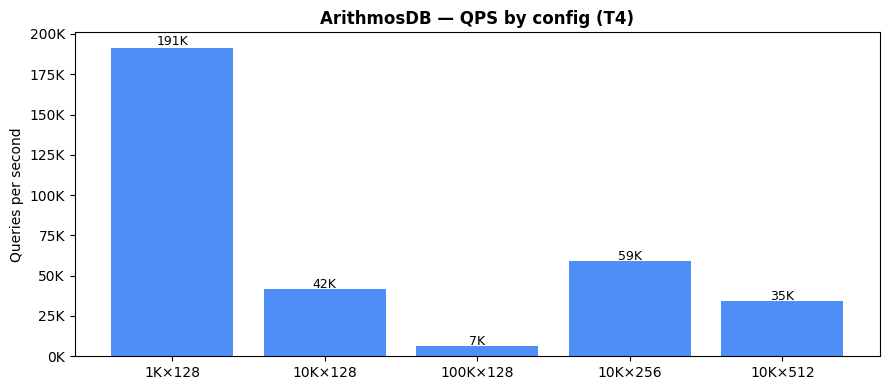

In [8]:
import matplotlib.pyplot as plt
labels = [r['label'] for r in results]
qps    = [r['qps']   for r in results]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, qps, color='#4f8ef7')
ax.set_title('ArithmosDB — QPS by config (T4)', fontweight='bold')
ax.set_ylabel('Queries per second')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for b, v in zip(bars, qps):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
            f'{v/1000:.0f}K', ha='center', fontsize=9)
plt.tight_layout()
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/benchmark.png', dpi=150)
plt.show()